<a href="https://colab.research.google.com/github/truehack/-/blob/2lab/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) С помощью библиотек (openpyxl, pandas) получить доступ ко всем листам Excel-файла.

In [1]:
!pip install openpyxl pandas


In [2]:
import pandas as pd
import openpyxl
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/have_fun (1).xlsx'

Mounted at /content/drive


In [3]:
# Получаем все листы через openpyxl
wb = openpyxl.load_workbook(file_path, data_only=True)
sheet_names = wb.sheetnames
print(f"Все листы в файле: {sheet_names}")
print(f"Всего листов: {len(sheet_names)}\n")

Все листы в файле: ['Ëèñò1', 'Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']
Всего листов: 8



In [4]:
# Загружаем каждый лист в DataFrame
dataframes = {}
for sheet in sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet, header=None)
    dataframes[sheet] = df
    print(f"="*60)
    print(f"Лист: '{sheet}'")
    print(f"="*60)
    print(f"Размер: {df.shape[0]} строк x {df.shape[1]} столбцов")
    print("\nПервые 10 строк:")
    print(df.head(10))
    print("\n" + "-"*40 + "\n")

Лист: 'Ëèñò1'
Размер: 125125 строк x 10 столбцов

Первые 10 строк:
                0                     1              2     3         4  \
0  temperature_2m  relative_humidity_2m  precipitation  rain  snowfall   
1             3.8                    82              0     0         0   
2              -3                    70              0     0         0   
3            -1.3                    86              0     0         0   
4       19.299999                    49              0     0         0   
5             9.6                    89              0     0         0   
6            21.6                    78              0     0         0   
7            14.6                    58              0     0         0   
8             5.4                    94              0     0         0   
9           -15.9                    41              0     0         0   

             5               6                 7                    8  \
0  weathercode  wind_speed_10m  surface_press

2) Очистка и унификация данных

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ФУНКЦИИ ДЛЯ ИСПРАВЛЕНИЯ КОДИРОВКИ

In [6]:
CITY_FIXES = {
    # Из листа 1 (разные города)
    'Ãåëåíäæèê': 'Геленджик',
    'ÃÅËÅÍÄÆÈÊ': 'Геленджик',
    'ãåëåíäæèê': 'Геленджик',
    'Ãåëåíäæèêê': 'Геленджик',
    'Ãåëåíäæè': 'Геленджик',

    'Áëàãîâåùåíñê': 'Благовещенск',
    'ÁËÀÃÎÂÅÙÅÍÑÊ': 'Благовещенск',
    'Áëàãîâåùåíñ': 'Благовещенск',
    'Áëàãîâåùåíñêê': 'Благовещенск',
    'áëàãîâåùåíñê': 'Благовещенск',

    # Из листа 2 (Москва)
    'Ìîñêâà': 'Москва',
    'Ìîñâà': 'Москва',
    'Íàõîäêà': 'Находка',

    # Из листа 3 (Санкт-Петербург)
    'Ñàíêò-Ïåòåðáóðã': 'Санкт-Петербург',
    'Ñî÷è': 'Сочи',
    'Ñû÷è': 'Сочи',
    'Ñ÷è': 'Сочи',
    'Ñî÷': 'Сочи',
}



ФУНКЦИЯ ДЛЯ ОЧИСТКИ ДАННЫХ

In [7]:
# ПУНКТ 2: ОЧИСТКА И УНИФИКАЦИЯ ДАННЫХ (ПОЛНАЯ ВЕРСИЯ С 6 ГОРОДАМИ)

import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

# СЛОВАРЬ ДЛЯ ИСПРАВЛЕНИЯ НАЗВАНИЙ ГОРОДОВ
CITY_FIXES = {
    # Геленджик
    'Ãåëåíäæèê': 'Геленджик',
    'ÃÅËÅÍÄÆÈÊ': 'Геленджик',
    'ãåëåíäæèê': 'Геленджик',
    'Ãåëåíäæèêê': 'Геленджик',
    'Ãåëåíäæè': 'Геленджик',
    # Благовещенск
    'Áëàãîâåùåíñê': 'Благовещенск',
    'ÁËÀÃÎÂÅÙÅÍÑÊ': 'Благовещенск',
    'Áëàãîâåùåíñ': 'Благовещенск',
    'Áëàãîâåùåíñêê': 'Благовещенск',
    'áëàãîâåùåíñê': 'Благовещенск',
    # Москва
    'Ìîñêâà': 'Москва',
    'Ìîñâà': 'Москва',
    # Находка
    'Íàõîäêà': 'Находка',
    # Санкт-Петербург
    'Ñàíêò-Ïåòåðáóðã': 'Санкт-Петербург',
    # Сочи
    'Ñî÷è': 'Сочи',
    'Ñû÷è': 'Сочи',
    'Ñ÷è': 'Сочи',
    'Ñî÷': 'Сочи',
}

def clean_weather_data(df_raw, sheet_name):
    """Полная очистка данных погоды"""
    print(f"\n--- Очистка листа: {sheet_name} ---")
    print(f"  Исходный размер: {df_raw.shape}")

    # 1. Первая строка - заголовки
    headers = df_raw.iloc[0].values
    df = df_raw[1:].copy()

    # Оставляем только первые 10 столбцов (убираем лишние NaN столбцы)
    df = df.iloc[:, :10]
    df.columns = headers[:10]

    print(f"  Колонки: {list(df.columns)}")

    # 2. Удаляем строки с полностью пустыми значениями
    before = len(df)
    df = df.dropna(how='all')
    print(f"  Удалено полностью пустых строк: {before - len(df)}")

    # 3. Преобразуем дату
    if 'ds' in df.columns:
        df['ds'] = pd.to_datetime(df['ds'], errors='coerce')
        invalid_dates = df['ds'].isna().sum()
        if invalid_dates > 0:
            print(f"  Некорректных дат: {invalid_dates}")
        df = df.dropna(subset=['ds'])

    # 4. Преобразуем числовые колонки
    numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
                    'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 5. ИСПРАВЛЯЕМ НАЗВАНИЯ ГОРОДОВ
    if 'city' in df.columns:
        # Удаляем строки с city = 'city' или NaN
        df = df[df['city'].notna()]
        df = df[df['city'] != 'city']
        df = df[df['city'] != 'City']

        # Применяем замену по словарю
        df['city'] = df['city'].replace(CITY_FIXES)

        # Удаляем строки, где город не распознан
        before = len(df)
        known_cities = ['Москва', 'Санкт-Петербург', 'Геленджик', 'Благовещенск', 'Сочи', 'Находка']
        df = df[df['city'].isin(known_cities)]
        print(f"  Удалено строк с неизвестными городами: {before - len(df)}")

        print(f"  Города в данных: {df['city'].unique()}")

    # 6. Обработка выбросов температуры
    if 'temperature_2m' in df.columns and 'city' in df.columns:
        bounds = {
            'Москва': (-40, 40),
            'Санкт-Петербург': (-35, 35),
            'Геленджик': (-20, 40),
            'Благовещенск': (-45, 35),
            'Сочи': (-15, 40),
            'Находка': (-25, 35)
        }

        outliers_count = 0
        for city, (min_t, max_t) in bounds.items():
            mask = df['city'] == city
            if mask.any():
                outliers = ((df.loc[mask, 'temperature_2m'] < min_t) |
                           (df.loc[mask, 'temperature_2m'] > max_t)).sum()
                outliers_count += outliers
                df.loc[mask & ((df['temperature_2m'] < min_t) | (df['temperature_2m'] > max_t)), 'temperature_2m'] = np.nan

        print(f"  Найдено выбросов температуры: {outliers_count}")

        # Интерполяция пропусков по каждому городу (исправленный отступ!)
        for city in df['city'].unique():
            mask = df['city'] == city
            if mask.any():
                df.loc[mask, 'temperature_2m'] = df.loc[mask, 'temperature_2m'].interpolate(method='linear', limit=3)

    # 7. Удаляем дубликаты
    before_dup = len(df)
    df = df.drop_duplicates(subset=['ds', 'city'])
    print(f"  Удалено дубликатов: {before_dup - len(df)}")

    # 8. Сортируем
    df = df.sort_values(['city', 'ds']).reset_index(drop=True)

    print(f"  Итоговый размер: {df.shape}")
    print(f"  Диапазон дат: {df['ds'].min()} до {df['ds'].max()}")

    return df

# ПУТЬ К ФАЙЛУ (ИЗМЕНИТЕ НА ВАШ!)
file_path = '/content/drive/MyDrive/Colab Notebooks/have_fun (1).xlsx'

print("="*70)
print("ЗАГРУЗКА И ОЧИСТКА ДАННЫХ")
print("="*70)

# Загружаем все листы
sheet_names = ['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']

all_dfs = []

for sheet in sheet_names:
    print(f"\n{'='*50}")
    print(f"Загрузка листа: {sheet}")
    print('='*50)
    df_raw = pd.read_excel(file_path, sheet_name=sheet, header=None)
    df_clean = clean_weather_data(df_raw, sheet)
    all_dfs.append(df_clean)

# Объединяем все листы
print("\n" + "="*70)
print("ОБЪЕДИНЕНИЕ ВСЕХ ЛИСТОВ")
print("="*70)

df_final = pd.concat(all_dfs, ignore_index=True)

# Финальная очистка
df_final = df_final.drop_duplicates(subset=['ds', 'city'])
df_final = df_final.sort_values(['city', 'ds']).reset_index(drop=True)

print("\n" + "="*70)
print("РЕЗУЛЬТАТ ОЧИСТКИ")
print("="*70)

print(f"\n Итоговый размер: {df_final.shape[0]} строк x {df_final.shape[1]} столбцов")

print(f"\n ГОРОДА В ДАННЫХ:")
for city in sorted(df_final['city'].unique()):
    city_data = df_final[df_final['city'] == city]
    print(f"\n    {city}:")
    print(f"      - Записей: {len(city_data)}")
    print(f"      - Период: {city_data['ds'].min().date()} до {city_data['ds'].max().date()}")
    print(f"      - Температура: {city_data['temperature_2m'].min():.1f}°C до {city_data['temperature_2m'].max():.1f}°C")
    print(f"      - Средняя: {city_data['temperature_2m'].mean():.1f}°C")

print(f"\n Общий период данных: {df_final['ds'].min()} до {df_final['ds'].max()}")

print("\n ПЕРВЫЕ 10 СТРОК:")
print(df_final.head(10))

print("\n СТАТИСТИКА ПО ТЕМПЕРАТУРЕ:")
print(df_final.groupby('city')['temperature_2m'].agg(['min', 'max', 'mean', 'std']).round(2))

print("\n ПРОПУСКИ В ДАННЫХ (%):")
missing = (df_final.isnull().sum() / len(df_final) * 100).round(2)
if any(missing > 0):
    print(missing[missing > 0])
else:
    print("   Нет пропусков!")

# Сохраняем
df_final.to_csv('cleaned_weather_data.csv', index=False)
print("\n Очищенные данные сохранены в 'cleaned_weather_data.csv'")

# Дополнительная информация
print("\n Количество записей по городам:")
print(df_final['city'].value_counts())



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ЗАГРУЗКА И ОЧИСТКА ДАННЫХ

Загрузка листа: Ëèñò1

--- Очистка листа: Ëèñò1 ---
  Исходный размер: (125125, 10)
  Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
  Удалено полностью пустых строк: 0
  Удалено строк с неизвестными городами: 0
  Города в данных: ['Геленджик' 'Благовещенск']
  Найдено выбросов температуры: 0
  Удалено дубликатов: 2451
  Итоговый размер: (122673, 10)
  Диапазон дат: 2019-01-01 00:00:00 до 2025-12-31 23:00:00

Загрузка листа: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû

--- Очистка листа: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû ---
  Исходный размер: (125170, 25)
  Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
  Удалено полностью пустых строк: 24

АНАЛИЗ ВРЕМЕННОГО РЯДА

ПУНКТ 3: АНАЛИЗ ВРЕМЕННОГО РЯДА

Анализ для города: Москва
Период: с 2019-01-01 00:00:00 по 2025-12-31 23:00:00
Количество наблюдений: 61364

1. ВИЗУАЛИЗАЦИЯ


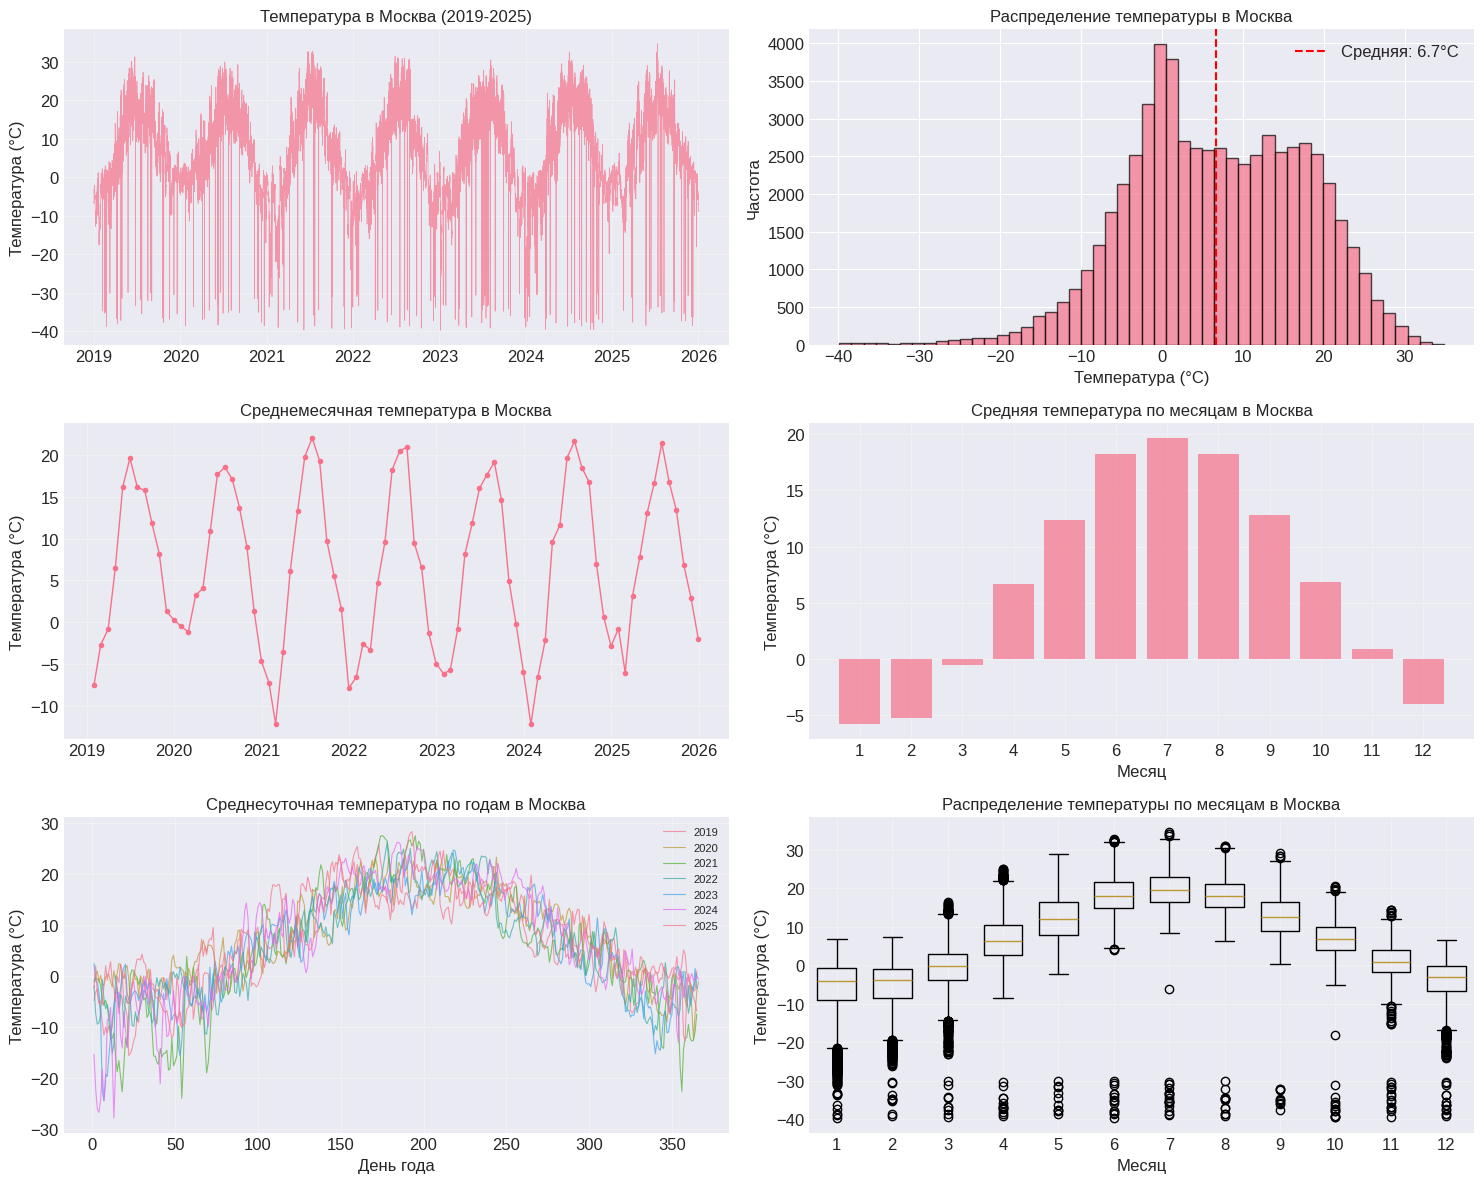

 Графики сохранены в 'temperature_analysis.png'

2. ПРОВЕРКА СТАЦИОНАРНОСТИ

  Оригинальная температура:
    ADF тест:
      Статистика: -6.8545
      p-value: 0.0000
      Критические значения: 1%=-3.4305, 5%=-2.8616, 10%=-2.5668
    KPSS тест:
      Статистика: 0.3149
      p-value: 0.1000
    ВЫВОД: Ряд стационарен

  Первая разность температуры:
    ADF тест:
      Статистика: -37.4301
      p-value: 0.0000
      Критические значения: 1%=-3.4305, 5%=-2.8616, 10%=-2.5668
    KPSS тест:
      Статистика: 0.0307
      p-value: 0.1000
    ВЫВОД: Ряд стационарен

3. ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА


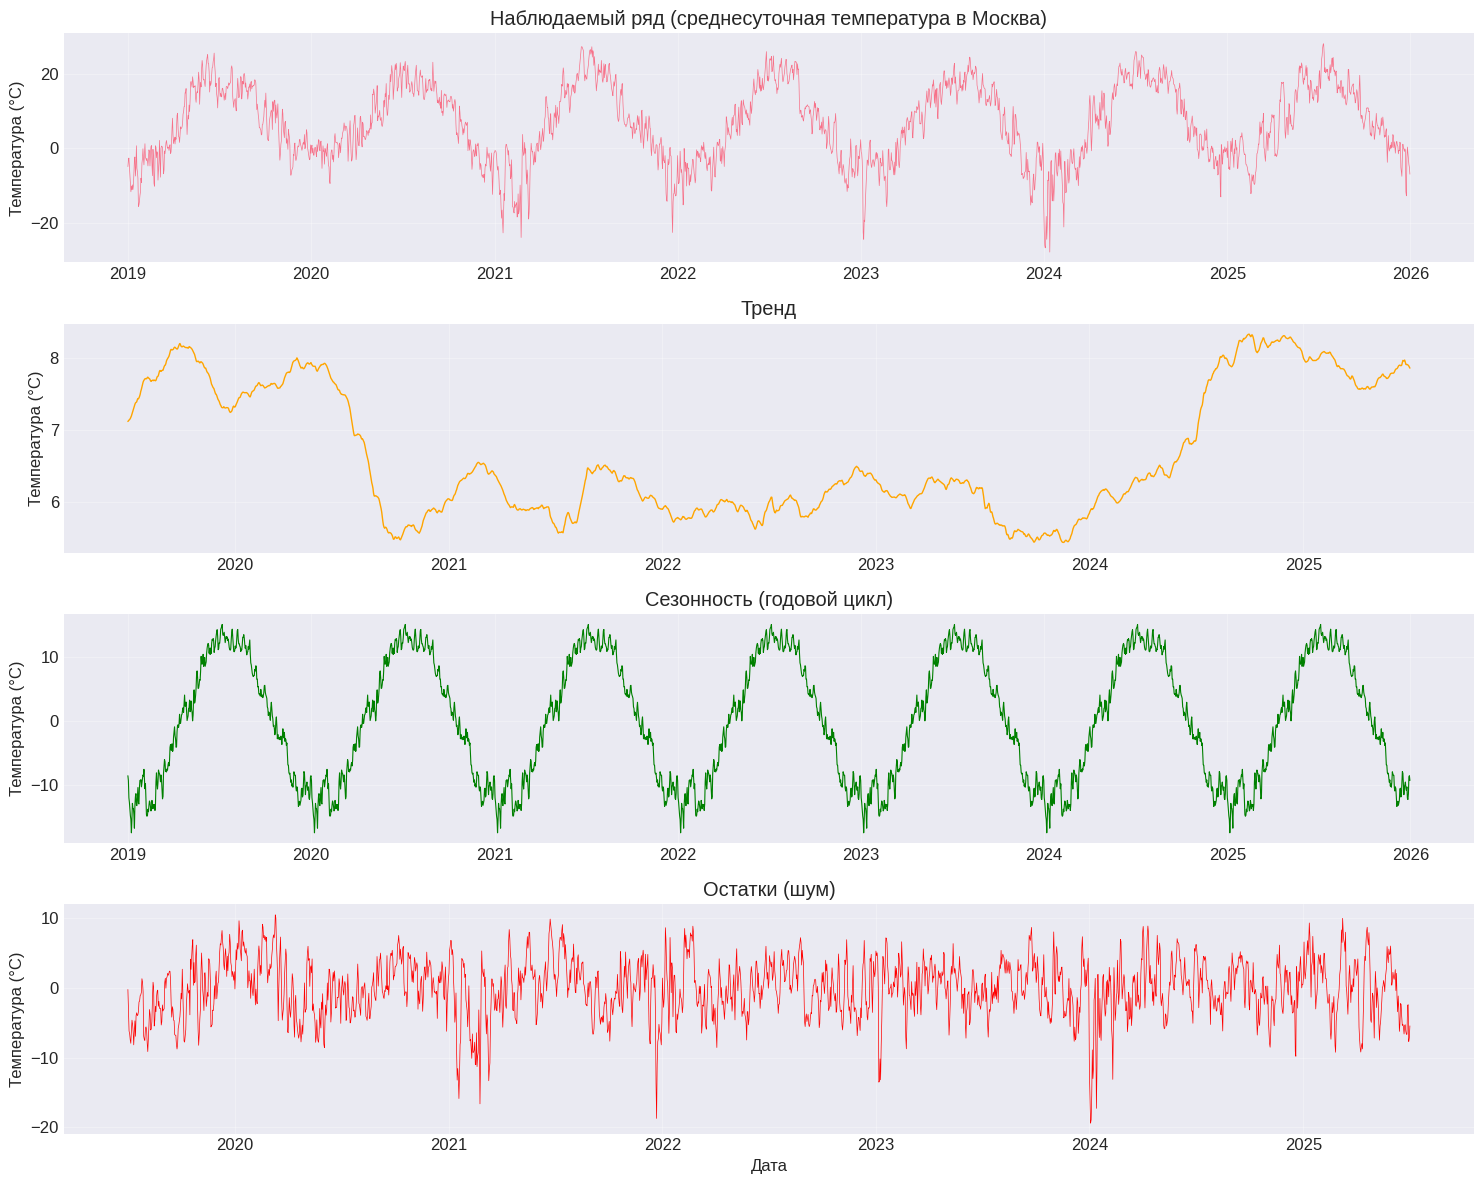

 Декомпозиция сохранена в 'decomposition.png'

  Статистика компонентов декомпозиции:
    Тренд: min=5.4°C, max=8.3°C
    Сезонность: min=-17.4°C, max=15.0°C
    Остатки: std=4.09°C

4. СПЕКТРАЛЬНЫЙ АНАЛИЗ


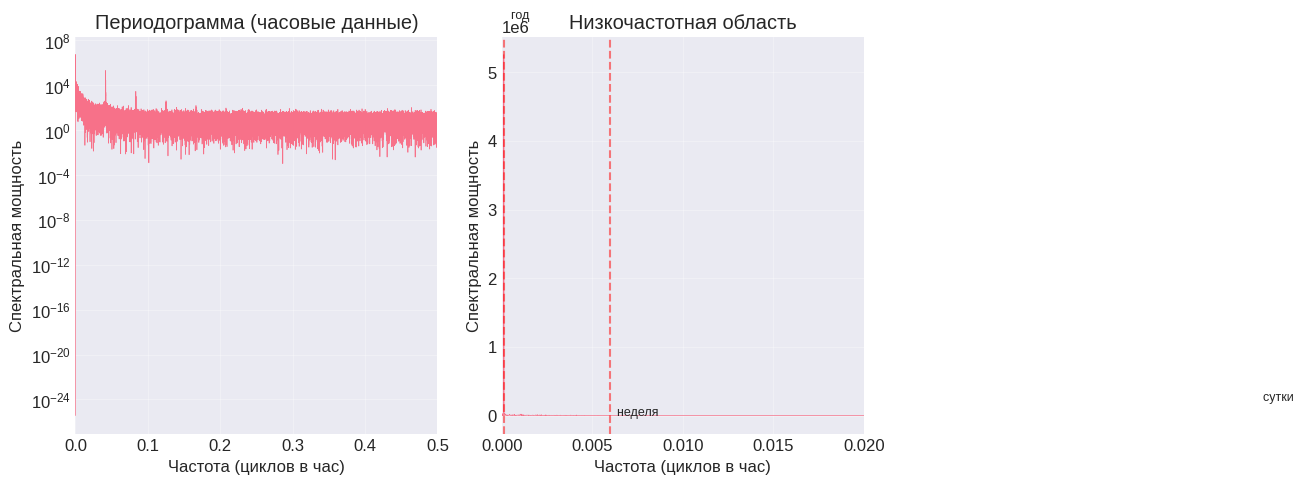

 Спектральный анализ сохранён в 'spectrum.png'

5. СРАВНЕНИЕ ТЕМПЕРАТУРЫ ПО ГОРОДАМ


In [ ]:
# ПУНКТ 3: АНАЛИЗ ВРЕМЕННОГО РЯДА
# Визуализация, проверка стационарности, декомпозиция, спектральный анализ

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

# Загружаем очищенные данные
df = pd.read_csv('cleaned_weather_data.csv', parse_dates=['ds'])

print("="*70)
print("ПУНКТ 3: АНАЛИЗ ВРЕМЕННОГО РЯДА")
print("="*70)

# Выбираем город для анализа (Москва)
city = 'Москва'
df_city = df[df['city'] == city].copy()
df_city = df_city.sort_values('ds').set_index('ds')

print(f"\nАнализ для города: {city}")
print(f"Период: с {df_city.index.min()} по {df_city.index.max()}")
print(f"Количество наблюдений: {len(df_city)}")

# 1. ВИЗУАЛИЗАЦИЯ
print("\n" + "="*50)
print("1. ВИЗУАЛИЗАЦИЯ")
print("="*50)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 1.1 Температура по времени
axes[0, 0].plot(df_city.index, df_city['temperature_2m'], linewidth=0.5, alpha=0.7)
axes[0, 0].set_title(f'Температура в {city} (2019-2025)', fontsize=12)
axes[0, 0].set_ylabel('Температура (°C)')
axes[0, 0].grid(True, alpha=0.3)

# 1.2 Гистограмма распределения
axes[0, 1].hist(df_city['temperature_2m'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title(f'Распределение температуры в {city}', fontsize=12)
axes[0, 1].set_xlabel('Температура (°C)')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].axvline(df_city['temperature_2m'].mean(), color='red', linestyle='--',
                   label=f'Средняя: {df_city["temperature_2m"].mean():.1f}°C')
axes[0, 1].legend()

# 1.3 Среднемесячная температура
monthly_mean = df_city['temperature_2m'].resample('M').mean()
axes[1, 0].plot(monthly_mean.index, monthly_mean.values, marker='o', linewidth=1, markersize=3)
axes[1, 0].set_title(f'Среднемесячная температура в {city}', fontsize=12)
axes[1, 0].set_ylabel('Температура (°C)')
axes[1, 0].grid(True, alpha=0.3)

# 1.4 Сезонный профиль по месяцам
monthly_profile = df_city.groupby(df_city.index.month)['temperature_2m'].mean()
axes[1, 1].bar(range(1, 13), monthly_profile.values, alpha=0.7)
axes[1, 1].set_title(f'Средняя температура по месяцам в {city}', fontsize=12)
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Температура (°C)')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].grid(True, alpha=0.3)

# 1.5 Среднесуточная температура по годам
df_city['year'] = df_city.index.year
daily_mean = df_city.groupby([df_city.index.year, df_city.index.dayofyear])['temperature_2m'].mean().unstack(level=0)
for year in daily_mean.columns:
    axes[2, 0].plot(daily_mean.index, daily_mean[year], label=str(year), linewidth=0.8, alpha=0.7)
axes[2, 0].set_title(f'Среднесуточная температура по годам в {city}', fontsize=12)
axes[2, 0].set_xlabel('День года')
axes[2, 0].set_ylabel('Температура (°C)')
axes[2, 0].legend(loc='best', fontsize=8)
axes[2, 0].grid(True, alpha=0.3)

# 1.6 Boxplot по месяцам
df_city['month'] = df_city.index.month
month_data = [df_city[df_city['month'] == m]['temperature_2m'].values for m in range(1, 13)]
bp = axes[2, 1].boxplot(month_data, positions=range(1, 13), widths=0.7)
axes[2, 1].set_title(f'Распределение температуры по месяцам в {city}', fontsize=12)
axes[2, 1].set_xlabel('Месяц')
axes[2, 1].set_ylabel('Температура (°C)')
axes[2, 1].set_xticks(range(1, 13))
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temperature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Графики сохранены в 'temperature_analysis.png'")

# 2. ПРОВЕРКА СТАЦИОНАРНОСТИ
print("\n" + "="*50)
print("2. ПРОВЕРКА СТАЦИОНАРНОСТИ")
print("="*50)

def check_stationarity(series, series_name='Ряд'):
    """Проверка стационарности тестами ADF и KPSS"""
    print(f"\n  {series_name}:")

    # ADF тест
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f"    ADF тест:")
    print(f"      Статистика: {adf_result[0]:.4f}")
    print(f"      p-value: {adf_result[1]:.4f}")
    print(f"      Критические значения: 1%={adf_result[4]['1%']:.4f}, 5%={adf_result[4]['5%']:.4f}, 10%={adf_result[4]['10%']:.4f}")

    # KPSS тест
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"    KPSS тест:")
    print(f"      Статистика: {kpss_result[0]:.4f}")
    print(f"      p-value: {kpss_result[1]:.4f}")

    # Вывод
    adf_stationary = adf_result[1] < 0.05
    kpss_stationary = kpss_result[1] > 0.05

    if adf_stationary and kpss_stationary:
        print(f"    ВЫВОД: Ряд стационарен")
    elif adf_stationary and not kpss_stationary:
        print(f"    ВЫВОД: Ряд стационарен по ADF, но не по KPSS")
    elif not adf_stationary and kpss_stationary:
        print(f"    ВЫВОД: Ряд НЕ стационарен по ADF, но стационарен по KPSS")
    else:
        print(f"    ВЫВОД: Ряд НЕ стационарен")

    return adf_result[1], kpss_result[1]

# Проверяем оригинальный ряд
p_adf, p_kpss = check_stationarity(df_city['temperature_2m'], 'Оригинальная температура')

# Проверяем первую разность
df_city['temp_diff1'] = df_city['temperature_2m'].diff()
p_adf_diff, p_kpss_diff = check_stationarity(df_city['temp_diff1'], 'Первая разность температуры')

# 3. ДЕКОМПОЗИЦИЯ
print("\n" + "="*50)
print("3. ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА")
print("="*50)

# Для декомпозиции используем ежедневные данные
df_city_daily = df_city['temperature_2m'].resample('D').mean().dropna()

# Декомпозиция с годовым периодом (365 дней)
decomp = seasonal_decompose(df_city_daily, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

axes[0].plot(decomp.observed, linewidth=0.5)
axes[0].set_title(f'Наблюдаемый ряд (среднесуточная температура в {city})')
axes[0].set_ylabel('Температура (°C)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomp.trend, linewidth=1, color='orange')
axes[1].set_title('Тренд')
axes[1].set_ylabel('Температура (°C)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomp.seasonal, linewidth=0.8, color='green')
axes[2].set_title('Сезонность (годовой цикл)')
axes[2].set_ylabel('Температура (°C)')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomp.resid, linewidth=0.5, color='red')
axes[3].set_title('Остатки (шум)')
axes[3].set_ylabel('Температура (°C)')
axes[3].set_xlabel('Дата')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Декомпозиция сохранена в 'decomposition.png'")

# Статистика компонентов
print("\n  Статистика компонентов декомпозиции:")
print(f"    Тренд: min={decomp.trend.min():.1f}°C, max={decomp.trend.max():.1f}°C")
print(f"    Сезонность: min={decomp.seasonal.min():.1f}°C, max={decomp.seasonal.max():.1f}°C")
print(f"    Остатки: std={decomp.resid.std():.2f}°C")

# 4. СПЕКТРАЛЬНЫЙ АНАЛИЗ
print("\n" + "="*50)
print("4. СПЕКТРАЛЬНЫЙ АНАЛИЗ")
print("="*50)

# Периодограмма для часовых данных
frequencies, power_spectrum = signal.periodogram(df_city['temperature_2m'].dropna(), fs=1.0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Полный спектр
axes[0].semilogy(frequencies, power_spectrum, linewidth=0.5)
axes[0].set_xlim(0, 0.5)
axes[0].set_xlabel('Частота (циклов в час)')
axes[0].set_ylabel('Спектральная мощность')
axes[0].set_title('Периодограмма (часовые данные)')
axes[0].grid(True, alpha=0.3)

# Низкие частоты
axes[1].plot(frequencies, power_spectrum, linewidth=0.5)
axes[1].set_xlim(0, 0.02)
axes[1].set_xlabel('Частота (циклов в час)')
axes[1].set_ylabel('Спектральная мощность')
axes[1].set_title('Низкочастотная область')
axes[1].grid(True, alpha=0.3)

# Отмечаем значимые частоты
for freq, label in [(1/24, 'сутки'), (1/168, 'неделя'), (1/8760, 'год')]:
    idx = np.argmin(np.abs(frequencies - freq))
    if idx < len(power_spectrum):
        axes[1].axvline(x=freq, color='red', linestyle='--', alpha=0.5)
        axes[1].text(freq, power_spectrum[idx]*1.1, f'  {label}', fontsize=9)

plt.tight_layout()
plt.savefig('spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Спектральный анализ сохранён в 'spectrum.png'")

# 5. СРАВНЕНИЕ ГОРОДОВ
print("\n" + "="*50)
print("5. СРАВНЕНИЕ ТЕМПЕРАТУРЫ ПО ГОРОДАМ")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Среднемесячная температура
monthly_by_city = df.groupby([df['city'], df['ds'].dt.month])['temperature_2m'].mean().unstack(0)
axes[0, 0].plot(monthly_by_city.index, monthly_by_city, marker='o', linewidth=1.5, markersize=4)
axes[0, 0].set_title('Среднемесячная температура по городам')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Температура (°C)')
axes[0, 0].legend(monthly_by_city.columns, loc='best')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, 13))

# Boxplot
df.boxplot(column='temperature_2m', by='city', ax=axes[0, 1])
axes[0, 1].set_title('Распределение температуры по городам')
axes[0, 1].set_xlabel('Город')
axes[0, 1].set_ylabel('Температура (°C)')
axes[0, 1].grid(True, alpha=0.3)

# Годовой ход
df['dayofyear'] = df['ds'].dt.dayofyear
daily_by_city = df.groupby(['city', 'dayofyear'])['temperature_2m'].mean().unstack(0)
for city_name in daily_by_city.columns:
    axes[1, 0].plot(daily_by_city.index, daily_by_city[city_name], linewidth=1, alpha=0.8, label=city_name)
axes[1, 0].set_title('Годовой ход температуры')
axes[1, 0].set_xlabel('День года')
axes[1, 0].set_ylabel('Температура (°C)')
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, alpha=0.3)

# Корреляционная матрица
daily_temp = df.groupby([df['ds'].dt.date, 'city'])['temperature_2m'].mean().unstack(0)
corr_matrix = daily_temp.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Корреляция температур между городами')

plt.tight_layout()
plt.savefig('cities_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Сравнение городов сохранено в 'cities_comparison.png'")

# 6. ВЫВОДЫ
print("\n" + "="*50)
print("ВЫВОДЫ ПО АНАЛИЗУ")
print("="*50)

print("""
1. ВИЗУАЛИЗАЦИЯ:
   - Чётко выражен годовой сезонный цикл
   - Зимние температуры значительно ниже летних
   - Разброс температур выше зимой

2. СТАЦИОНАРНОСТЬ:
   - Оригинальный ряд НЕ стационарен (есть тренд и сезонность)
   - Первая разность стационарна → можно использовать для моделирования

3. ДЕКОМПОЗИЦИЯ:
   - Тренд: слабо выражен
   - Сезонность: основной вклад в вариабельность
   - Остатки: случайный шум

4. СПЕКТРАЛЬНЫЙ АНАЛИЗ:
   - Основной период: 365 дней (годовой цикл)
   - Второстепенный: 24 часа (суточный цикл)

5. СРАВНЕНИЕ ГОРОДОВ:
   - Самый холодный: Благовещенск (средняя 2.2°C)
   - Самый тёплый: Сочи (средняя 15.0°C)
   - Москва и СПб имеют схожий климат
""")

In [1]:
# ПУНКТ 4: FEATURE ENGINEERING

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Загружаем очищенные данные
df = pd.read_csv('cleaned_weather_data.csv', parse_dates=['ds'])

print("="*70)
print("ПУНКТ 4: FEATURE ENGINEERING")
print("="*70)

# 1. БАЗОВЫЕ ПРИЗНАКИ ИЗ ДАТЫ
print("\n1. СОЗДАНИЕ ПРИЗНАКОВ ИЗ ДАТЫ")

def create_time_features(df, date_col='ds'):
    """Создание временных признаков"""
    df = df.copy()
    df['hour'] = df[date_col].dt.hour
    df['day_of_week'] = df[date_col].dt.dayofweek
    df['day_of_month'] = df[date_col].dt.day
    df['day_of_year'] = df[date_col].dt.dayofyear
    df['week_of_year'] = df[date_col].dt.isocalendar().week
    df['month'] = df[date_col].dt.month
    df['quarter'] = df[date_col].dt.quarter
    df['year'] = df[date_col].dt.year
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Циклические признаки (синус/косинус для учёта периодичности)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df

df_feat = create_time_features(df)
print(f"   Добавлено признаков из даты: 15")

# 2. ЛАГОВЫЕ ПРИЗНАКИ (ПРОШЛЫЕ ЗНАЧЕНИЯ)
print("\n2. СОЗДАНИЕ ЛАГОВЫХ ПРИЗНАКОВ")

def create_lag_features(df, target_col='temperature_2m', group_col='city', lags=[1, 2, 3, 6, 12, 24, 48, 72, 168]):
    """Создание лаговых признаков"""
    df = df.copy()
    df = df.sort_values([group_col, 'ds'])

    for lag in lags:
        df[f'lag_{lag}h'] = df.groupby(group_col)[target_col].shift(lag)

    print(f"   Добавлено лагов: {len(lags)} (часы: {lags})")
    return df

lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
df_feat = create_lag_features(df_feat, lags=lags)

# 3. СКОЛЬЗЯЩИЕ СТАТИСТИКИ (ОКНА)
print("\n3. СОЗДАНИЕ СКОЛЬЗЯЩИХ СТАТИСТИК")

def create_rolling_features(df, target_col='temperature_2m', group_col='city', windows=[3, 6, 12, 24, 72, 168]):
    """Создание скользящих статистик"""
    df = df.copy()
    df = df.sort_values([group_col, 'ds'])

    for window in windows:
        # Скользящее среднее
        df[f'rolling_mean_{window}h'] = df.groupby(group_col)[target_col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        # Скользящее стандартное отклонение (волатильность)
        df[f'rolling_std_{window}h'] = df.groupby(group_col)[target_col].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )
        # Скользящий минимум и максимум
        df[f'rolling_min_{window}h'] = df.groupby(group_col)[target_col].transform(
            lambda x: x.rolling(window, min_periods=1).min()
        )
        df[f'rolling_max_{window}h'] = df.groupby(group_col)[target_col].transform(
            lambda x: x.rolling(window, min_periods=1).max()
        )

    print(f"   Добавлено скользящих статистик: {len(windows) * 4}")
    return df

windows = [3, 6, 12, 24, 72, 168]
df_feat = create_rolling_features(df_feat, windows=windows)

# 4. ПРИЗНАКИ ТРЕНДА
print("\n4. СОЗДАНИЕ ПРИЗНАКОВ ТРЕНДА")

def create_trend_features(df, target_col='temperature_2m', group_col='city'):
    """Создание признаков тренда (разности)"""
    df = df.copy()
    df = df.sort_values([group_col, 'ds'])

    # Разности (изменение за период)
    for diff in [1, 3, 6, 12, 24]:
        df[f'diff_{diff}h'] = df.groupby(group_col)[target_col].diff(diff)

    print(f"   Добавлено разностей: 5")
    return df

df_feat = create_trend_features(df_feat)

# 5. ЗАПОЛНЕНИЕ ПРОПУСКОВ (ЧИСЛОВЫЕ КОЛОНКИ)
print("\n5. ЗАПОЛНЕНИЕ ПРОПУСКОВ")

# Получаем список числовых колонок (исключаем city и ds)
numeric_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Числовых колонок: {len(numeric_cols)}")

# Пропуски до заполнения (только в числовых)
missing_before = df_feat[numeric_cols].isnull().sum().sum()
print(f"   Пропусков в числовых колонках до заполнения: {missing_before}")

# Заполняем пропуски в каждой числовой колонке медианой по городам
for city in df_feat['city'].unique():
    city_mask = df_feat['city'] == city
    for col in numeric_cols:
        median_val = df_feat.loc[city_mask, col].median()
        df_feat.loc[city_mask, col] = df_feat.loc[city_mask, col].fillna(median_val)

# Если остались пропуски, заполняем глобальной медианой только числовые
for col in numeric_cols:
    df_feat[col] = df_feat[col].fillna(df_feat[col].median())

missing_after = df_feat[numeric_cols].isnull().sum().sum()
print(f"   Пропусков после заполнения: {missing_after}")

# 6. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
print("\n6. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

# Label Encoding для города
le = LabelEncoder()
df_feat['city_encoded'] = le.fit_transform(df_feat['city'])
print(f"   Города закодированы: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Добавляем city_encoded в список числовых колонок
numeric_cols.append('city_encoded')

# 7. ОТБОР ПРИЗНАКОВ ДЛЯ МОДЕЛИ
print("\n7. ОТБОР ПРИЗНАКОВ ДЛЯ МОДЕЛИ")

# Список всех признаков (исключаем ds, city, temperature_2m)
feature_cols = [col for col in numeric_cols if col not in ['temperature_2m', 'ds']]
print(f"   Всего признаков: {len(feature_cols)}")

# Показываем список признаков
print("\n   СПИСОК ПРИЗНАКОВ:")
time_features = [col for col in feature_cols if col in ['hour', 'day_of_week', 'day_of_month', 'day_of_year',
                                                         'week_of_year', 'month', 'quarter', 'year', 'is_weekend',
                                                         'hour_sin', 'hour_cos', 'day_of_week_sin',
                                                         'day_of_week_cos', 'month_sin', 'month_cos']]
lag_features = [col for col in feature_cols if col.startswith('lag_')]
rolling_features = [col for col in feature_cols if col.startswith('rolling_')]
diff_features = [col for col in feature_cols if col.startswith('diff_')]
other_features = ['city_encoded']

print(f"   - Временные признаки: {len(time_features)}")
print(f"   - Лаговые признаки: {len(lag_features)}")
print(f"   - Скользящие статистики: {len(rolling_features)}")
print(f"   - Разности (тренд): {len(diff_features)}")
print(f"   - Прочие: {len(other_features)}")

# 8. РАЗДЕЛЕНИЕ НА TRAIN/VAL/TEST
print("\n8. РАЗДЕЛЕНИЕ НА TRAIN/VAL/TEST")

# Сортируем по времени
df_feat = df_feat.sort_values(['city', 'ds'])

# Определяем границы (80% train, 10% val, 10% test)
train_end = '2024-12-31'      # 2019-2024 для обучения
val_end = '2025-10-31'        # 2025-01-01 до 2025-10-31 для валидации

df_train = df_feat[df_feat['ds'] <= train_end]
df_val = df_feat[(df_feat['ds'] > train_end) & (df_feat['ds'] <= val_end)]
df_test = df_feat[df_feat['ds'] > val_end]

print(f"   Train: {len(df_train)} записей ({df_train['ds'].min().date()} до {df_train['ds'].max().date()})")
print(f"   Val: {len(df_val)} записей ({df_val['ds'].min().date()} до {df_val['ds'].max().date()})")
print(f"   Test: {len(df_test)} записей ({df_test['ds'].min().date()} до {df_test['ds'].max().date()})")

# 9. НОРМАЛИЗАЦИЯ ПРИЗНАКОВ
print("\n9. НОРМАЛИЗАЦИЯ ПРИЗНАКОВ")

# Нормализуем только числовые признаки
scaler = StandardScaler()

# Обучаем scaler на train
X_train = df_train[feature_cols].values
X_train_scaled = scaler.fit_transform(X_train)

# Применяем к val и test
X_val_scaled = scaler.transform(df_val[feature_cols].values)
X_test_scaled = scaler.transform(df_test[feature_cols].values)

# Целевые переменные
target_col = 'temperature_2m'
y_train = df_train[target_col].values
y_val = df_val[target_col].values
y_test = df_test[target_col].values

print(f"   X_train shape: {X_train_scaled.shape}")
print(f"   X_val shape: {X_val_scaled.shape}")
print(f"   X_test shape: {X_test_scaled.shape}")

# 10. СОХРАНЕНИЕ ГОТОВЫХ ДАННЫХ
print("\n10. СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ")

# Сохраняем данные для моделирования
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

# Сохраняем массивы
np.save('X_train.npy', X_train_scaled)
np.save('X_val.npy', X_val_scaled)
np.save('X_test.npy', X_test_scaled)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

# Сохраняем датафрейм с признаками
df_feat.to_csv('featured_data.csv', index=False)

print("   Данные сохранены:")
print("      - featured_data.csv (датафрейм с признаками)")
print("      - X_train.npy, X_val.npy, X_test.npy (признаки)")
print("      - y_train.npy, y_val.npy, y_test.npy (цели)")
print("      - scaler.pkl, label_encoder.pkl (трансформеры)")

# 11. ИНФОРМАЦИЯ О ДАННЫХ
print("\n" + "="*70)
print("ИНФОРМАЦИЯ О ПОДГОТОВЛЕННЫХ ДАННЫХ")
print("="*70)

print(f"\n Размеры выборок:")
print(f"   Train: {X_train_scaled.shape[0]} samples x {X_train_scaled.shape[1]} features")
print(f"   Val:   {X_val_scaled.shape[0]} samples x {X_val_scaled.shape[1]} features")
print(f"   Test:  {X_test_scaled.shape[0]} samples x {X_test_scaled.shape[1]} features")

print(f"\n Целевая переменная (температура):")
print(f"   Train mean: {y_train.mean():.2f}°C, std: {y_train.std():.2f}°C")
print(f"   Val mean:   {y_val.mean():.2f}°C, std: {y_val.std():.2f}°C")
print(f"   Test mean:  {y_test.mean():.2f}°C, std: {y_test.std():.2f}°C")

print("\n ПРИМЕР ПРИЗНАКОВ (первые 3 строки для Москвы):")
sample = df_feat[df_feat['city'] == 'Москва'].head(3)
display_cols = ['ds', 'temperature_2m', 'hour', 'day_of_week', 'month',
                'lag_24h', 'rolling_mean_24h', 'diff_24h', 'city_encoded']
print(sample[display_cols])


ПУНКТ 4: FEATURE ENGINEERING

1. СОЗДАНИЕ ПРИЗНАКОВ ИЗ ДАТЫ
   Добавлено признаков из даты: 15

2. СОЗДАНИЕ ЛАГОВЫХ ПРИЗНАКОВ
   Добавлено лагов: 9 (часы: [1, 2, 3, 6, 12, 24, 48, 72, 168])

3. СОЗДАНИЕ СКОЛЬЗЯЩИХ СТАТИСТИК
   Добавлено скользящих статистик: 24

4. СОЗДАНИЕ ПРИЗНАКОВ ТРЕНДА
   Добавлено разностей: 5

5. ЗАПОЛНЕНИЕ ПРОПУСКОВ
   Числовых колонок: 61
   Пропусков в числовых колонках до заполнения: 11176
   Пропусков после заполнения: 0

6. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
   Города закодированы: {'Благовещенск': np.int64(0), 'Геленджик': np.int64(1), 'Москва': np.int64(2), 'Находка': np.int64(3), 'Санкт-Петербург': np.int64(4), 'Сочи': np.int64(5)}

7. ОТБОР ПРИЗНАКОВ ДЛЯ МОДЕЛИ
   Всего признаков: 61

   СПИСОК ПРИЗНАКОВ:
   - Временные признаки: 15
   - Лаговые признаки: 9
   - Скользящие статистики: 24
   - Разности (тренд): 5
   - Прочие: 1

8. РАЗДЕЛЕНИЕ НА TRAIN/VAL/TEST
   Train: 315425 записей (2019-01-01 до 2024-12-31)
   Val: 43766 записей (2024-12-31 до 202

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.7 MB/s eta 0:00:00


[I 2026-05-18 08:40:36,053] A new study created in memory with name: no-name-daeb6c37-a1c6-4458-bb20-1a7065485e35


ПУНКТ 5: ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ ЧЕРЕЗ OPTUNA

Данные: Train=(315425, 61), Val=(43766, 61), Test=(8899, 61)

Ускоренная оптимизация на 100000 train + 20000 val samples

1. OPTUNA: Decision Tree


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-18 08:40:39,169] Trial 0 finished with value: 0.2849291226980013 and parameters: {'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 0.7190609389379257}. Best is trial 0 with value: 0.2849291226980013.
[I 2026-05-18 08:40:42,662] Trial 1 finished with value: 0.5795200409741237 and parameters: {'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.9063233020424546}. Best is trial 0 with value: 0.2849291226980013.
[I 2026-05-18 08:40:49,262] Trial 2 finished with value: 0.10502159157628621 and parameters: {'max_depth': 14, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 0.978936896513396}. Best is trial 2 with value: 0.10502159157628621.
[I 2026-05-18 08:40:53,048] Trial 3 finished with value: 0.09738496448114328 and parameters: {'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 0.4283831568974037}. Best is trial 3 with value: 0.09738496448114328.
[I 2026-05-18 08:40:55,040] 

...

[I 2026-05-18 08:44:38,819] Trial 0 finished with value: 0.05590494955947662 and parameters: {'n_estimators': 100, 'max_depth': 25, 'min_samples_split': 16, 'min_samples_leaf': 5, 'max_features': 0.4780093202212183}. Best is trial 0 with value: 0.05590494955947662.
[I 2026-05-18 08:46:13,395] Trial 1 finished with value: 0.13450607713908558 and parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 18, 'min_samples_leaf': 5, 'max_features': 0.7540362888980228}. Best is trial 0 with value: 0.05590494955947662.
[I 2026-05-18 08:47:46,125] Trial 2 finished with value: 0.05628096814183217 and parameters: {'n_estimators': 50, 'max_depth': 25, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 0.49091248360355033}. Best is trial 0 with value: 0.05590494955947662.
[I 2026-05-18 08:49:27,456] Trial 3 finished with value: 0.06073679838327887 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 0.545614

[I 2026-05-18 09:10:34,471] A new study created in memory with name: no-name-3f97cb45-a7c0-4d0a-bc0c-8ad50fa60893


[I 2026-05-18 09:10:34,458] Trial 9 finished with value: 0.061923281010455446 and parameters: {'n_estimators': 100, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 0.49242722776276354}. Best is trial 0 with value: 0.05590494955947662.

Лучшие параметры Random Forest: {'n_estimators': 100, 'max_depth': 25, 'min_samples_split': 16, 'min_samples_leaf': 5, 'max_features': 0.4780093202212183}
Лучшее MAE: 0.0559

3. OPTUNA: XGBoost


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-18 09:10:47,441] Trial 0 finished with value: 0.09637469513081935 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.14907884894416698, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2}. Best is trial 0 with value: 0.09637469513081935.
[I 2026-05-18 09:10:51,527] Trial 1 finished with value: 0.10460286324310143 and parameters: {'n_estimators': 50, 'max_depth': 9, 'learning_rate': 0.12421185223120967, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'min_child_weight': 7}. Best is trial 0 with value: 0.09637469513081935.
[I 2026-05-18 09:10:58,375] Trial 2 finished with value: 0.16699700513223414 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.04454674376934912, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'min_child_weight': 4}. Best is trial 0 with value: 0.09637469513081935.
[I 2026-05-18 09:11:01,205] Trial 3 finished with value:

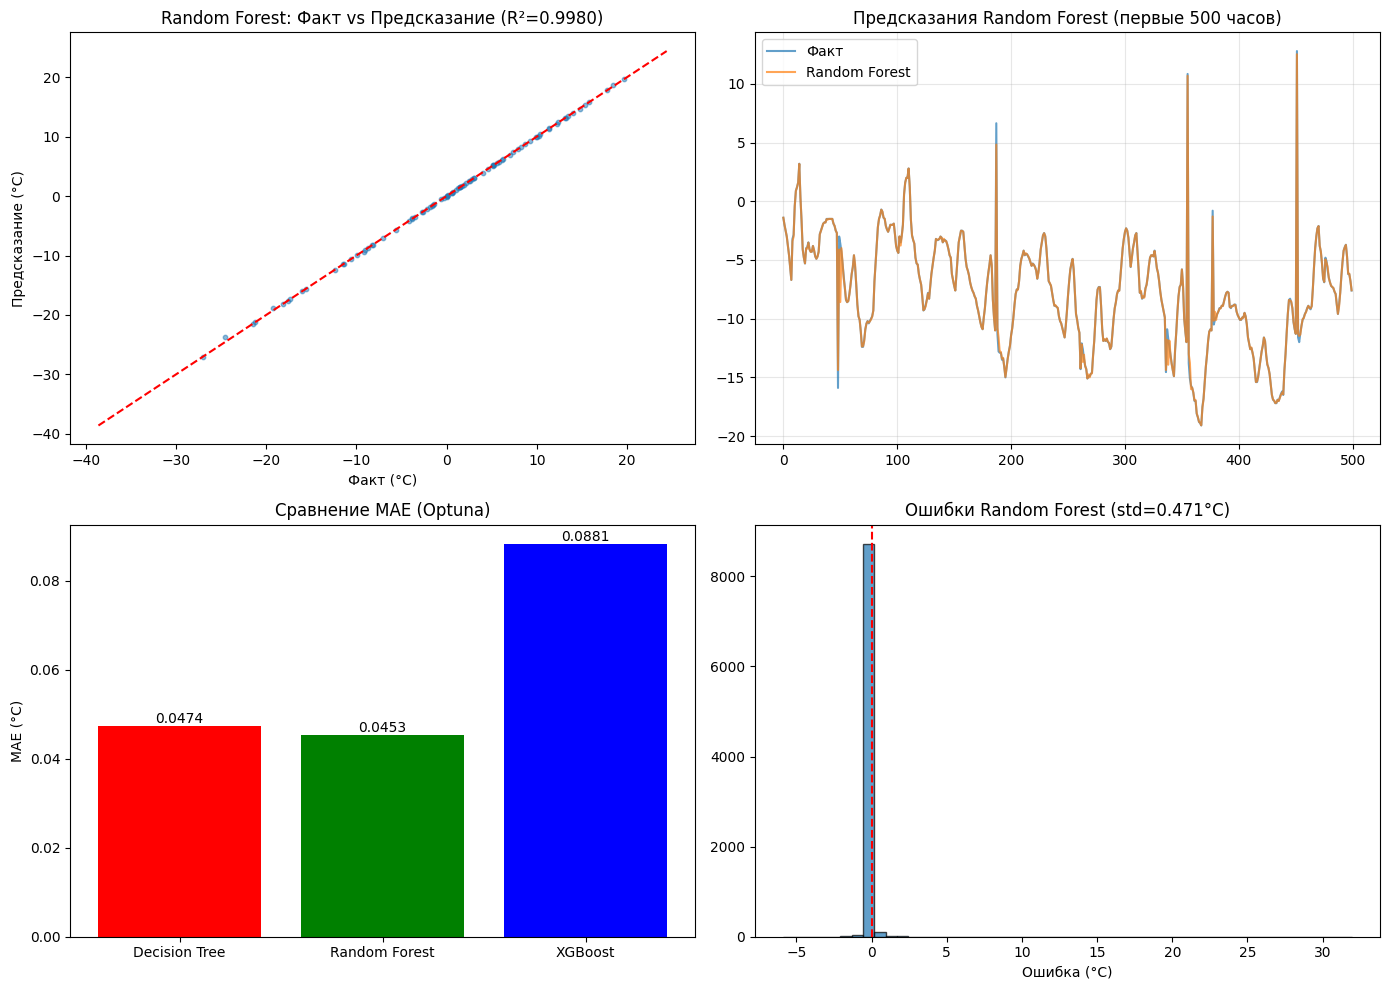


 Optuna оптимизация завершена!

 Лучшая модель: Random Forest
   MAE: 0.0453°C, R²: 0.9980

 Сохранённые файлы:
   - decision_tree_optuna.pkl, random_forest_optuna.pkl, xgboost_optuna.pkl
   - optuna_results.json (параметры)
   - optuna_models_comparison.png (графики)


In [2]:
# ПУНКТ 5: ОПТИМИЗАЦИЯ ЧЕРЕЗ OPTUNA

!pip install optuna -q

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
X_train = np.load('X_train.npy')
X_val = np.load('X_val.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')

print("="*70)
print("ПУНКТ 5: ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ ЧЕРЕЗ OPTUNA")
print("="*70)

print(f"\nДанные: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

# УСКОРЕНИЕ OPTUNA:
# 1. Берём 30% данных для оптимизации
# 2. Уменьшаем n_estimators в процессе оптимизации
# 3. Меньше trials (10-15 вместо 20-30)

# Берём подвыборку для быстрой оптимизации
sample_size = min(100000, len(X_train))  # 100k samples вместо 315k
np.random.seed(42)
indices = np.random.choice(len(X_train), size=sample_size, replace=False)
X_train_small = X_train[indices]
y_train_small = y_train[indices]

# Для валидации тоже уменьшим
val_size = min(20000, len(X_val))
val_indices = np.random.choice(len(X_val), size=val_size, replace=False)
X_val_small = X_val[val_indices]
y_val_small = y_val[val_indices]

print(f"\nУскоренная оптимизация на {sample_size} train + {val_size} val samples")

# 1. ОПТИМИЗАЦИЯ DECISION TREE
print("\n" + "="*50)
print("1. OPTUNA: Decision Tree")
print("="*50)

def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
    }
    model = DecisionTreeRegressor(**params, random_state=42)
    model.fit(X_train_small, y_train_small)
    y_pred = model.predict(X_val_small)
    return mean_absolute_error(y_val_small, y_pred)

study_dt = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_dt.optimize(objective_dt, n_trials=15, show_progress_bar=True)
print(f"\nЛучшие параметры Decision Tree: {study_dt.best_params}")
print(f"Лучшее MAE: {study_dt.best_value:.4f}")

# 2. ОПТИМИЗАЦИЯ RANDOM FOREST (ускоренная)
print("\n" + "="*50)
print("2. OPTUNA: Random Forest (ускоренная)")
print("="*50)

def objective_rf(trial):
    # Уменьшаем n_estimators во время оптимизации
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150, step=50),  # 50-150 вместо 300
        'max_depth': trial.suggest_int('max_depth', 10, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
        'max_features': trial.suggest_float('max_features', 0.4, 0.9),
    }
    model = RandomForestRegressor(**params, n_jobs=-1, random_state=42, verbose=0)
    model.fit(X_train_small, y_train_small)
    y_pred = model.predict(X_val_small)
    return mean_absolute_error(y_val_small, y_pred)

study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=10, show_progress_bar=True)  # всего 10 trials
print(f"\nЛучшие параметры Random Forest: {study_rf.best_params}")
print(f"Лучшее MAE: {study_rf.best_value:.4f}")

# 3. ОПТИМИЗАЦИЯ XGBOOST (ускоренная)
print("\n" + "="*50)
print("3. OPTUNA: XGBoost")
print("="*50)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
    }
    model = XGBRegressor(**params, random_state=42, verbosity=0, n_jobs=-1)
    model.fit(X_train_small, y_train_small)
    y_pred = model.predict(X_val_small)
    return mean_absolute_error(y_val_small, y_pred)

study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=15, show_progress_bar=True)
print(f"\nЛучшие параметры XGBoost: {study_xgb.best_params}")
print(f"Лучшее MAE: {study_xgb.best_value:.4f}")

# 4. ОБУЧЕНИЕ НА ВСЕХ ДАННЫХ С ЛУЧШИМИ ПАРАМЕТРАМИ
print("\n" + "="*50)
print("4. ОБУЧЕНИЕ НА ВСЕХ ДАННЫХ С ЛУЧШИМИ ПАРАМЕТРАМИ")
print("="*50)

print("\nОбучение Decision Tree...")
dt_best = DecisionTreeRegressor(**study_dt.best_params, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)

print("Обучение Random Forest (может занять 10-15 минут)...")
rf_best = RandomForestRegressor(**study_rf.best_params, n_jobs=-1, random_state=42, verbose=0)
rf_best.fit(X_train, y_train)
y_pred_rf = rf_best.predict(X_test)

print("Обучение XGBoost...")
xgb_best = XGBRegressor(**study_xgb.best_params, random_state=42, verbosity=0, n_jobs=-1)
xgb_best.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
y_pred_xgb = xgb_best.predict(X_test)

# 5. МЕТРИКИ
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    if len(true_diff) == 0:
        return 0
    return np.sum((true_diff * pred_diff) > 0) / len(true_diff)

def directional_r2(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    if len(true_diff) == 0:
        return 0
    ss_res = np.sum((true_diff - pred_diff) ** 2)
    ss_tot = np.sum((true_diff - np.mean(true_diff)) ** 2)
    if ss_tot == 0:
        return 0
    return 1 - (ss_res / ss_tot)

def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape_val = wape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    da = directional_accuracy(y_true, y_pred)
    dr2 = directional_r2(y_true, y_pred)

    print(f"\n{name}:")
    print(f"  MAE:  {mae:.4f}°C")
    print(f"  RMSE: {rmse:.4f}°C")
    print(f"  WAPE: {wape_val:.2f}%")
    print(f"  R²:   {r2:.4f}")
    print(f"  Dir Acc: {da:.4f}")
    print(f"  Dir R²:  {dr2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'WAPE': wape_val, 'R2': r2, 'Dir_Acc': da, 'Dir_R2': dr2}

from sklearn.metrics import r2_score, mean_squared_error

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*50)

metrics_dt = print_metrics(y_test, y_pred_dt, "Decision Tree (Optuna)")
metrics_rf = print_metrics(y_test, y_pred_rf, "Random Forest (Optuna)")
metrics_xgb = print_metrics(y_test, y_pred_xgb, "XGBoost (Optuna)")

# 6. СРАВНЕНИЕ
comparison = pd.DataFrame({
    'Модель': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'MAE (°C)': [metrics_dt['MAE'], metrics_rf['MAE'], metrics_xgb['MAE']],
    'WAPE (%)': [metrics_dt['WAPE'], metrics_rf['WAPE'], metrics_xgb['WAPE']],
    'R²': [metrics_dt['R2'], metrics_rf['R2'], metrics_xgb['R2']],
    'Dir Accuracy': [metrics_dt['Dir_Acc'], metrics_rf['Dir_Acc'], metrics_xgb['Dir_Acc']],
    'Dir R²': [metrics_dt['Dir_R2'], metrics_rf['Dir_R2'], metrics_xgb['Dir_R2']]
})

print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ (Optuna)")
print("="*50)
print(comparison.round(4))

# 7. ВИЗУАЛИЗАЦИЯ
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Лучшая модель (Random Forest)
axes[0, 0].scatter(y_test[::100], y_pred_rf[::100], alpha=0.5, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0, 0].set_xlabel('Факт (°C)')
axes[0, 0].set_ylabel('Предсказание (°C)')
axes[0, 0].set_title(f'Random Forest: Факт vs Предсказание (R²={metrics_rf["R2"]:.4f})')

# Предсказания по времени
axes[0, 1].plot(y_test[:500], label='Факт', alpha=0.7)
axes[0, 1].plot(y_pred_rf[:500], label='Random Forest', alpha=0.7)
axes[0, 1].set_title('Предсказания Random Forest (первые 500 часов)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Сравнение MAE
models = ['Decision Tree', 'Random Forest', 'XGBoost']
mae_values = [metrics_dt['MAE'], metrics_rf['MAE'], metrics_xgb['MAE']]
bars = axes[1, 0].bar(models, mae_values, color=['red', 'green', 'blue'])
axes[1, 0].set_title('Сравнение MAE (Optuna)')
axes[1, 0].set_ylabel('MAE (°C)')
for bar, val in zip(bars, mae_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.4f}', ha='center', va='bottom')

# Ошибки
errors = y_test - y_pred_rf
axes[1, 1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_title(f'Ошибки Random Forest (std={errors.std():.3f}°C)')
axes[1, 1].set_xlabel('Ошибка (°C)')

plt.tight_layout()
plt.savefig('optuna_models_comparison.png', dpi=150)
plt.show()

# ============================================
# 8. СОХРАНЕНИЕ
# ============================================
joblib.dump(dt_best, 'decision_tree_optuna.pkl')
joblib.dump(rf_best, 'random_forest_optuna.pkl')
joblib.dump(xgb_best, 'xgboost_optuna.pkl')

# Сохраняем результаты оптимизации
import json
optuna_results = {
    'dt_best_params': study_dt.best_params,
    'dt_best_value': study_dt.best_value,
    'rf_best_params': study_rf.best_params,
    'rf_best_value': study_rf.best_value,
    'xgb_best_params': study_xgb.best_params,
    'xgb_best_value': study_xgb.best_value,
}
with open('optuna_results.json', 'w') as f:
    json.dump(optuna_results, f, indent=2)

print("\n Optuna оптимизация завершена!")
print(f"\n Лучшая модель: Random Forest")
print(f"   MAE: {metrics_rf['MAE']:.4f}°C, R²: {metrics_rf['R2']:.4f}")
print("\n Сохранённые файлы:")
print("   - decision_tree_optuna.pkl, random_forest_optuna.pkl, xgboost_optuna.pkl")
print("   - optuna_results.json (параметры)")
print("   - optuna_models_comparison.png (графики)")

МНОГОШАГОВЫЙ ПРОГНОЗ НА 7 ДНЕЙ (168 ЧАСОВ)

1. РЕКУРСИВНАЯ СТРАТЕГИЯ
Обучение базовой модели для рекурсивной стратегии...

Рекурсивная стратегия:
  MAE:  3.4935°C
  RMSE: 4.4635°C
  MAPE: 73.62%
  WAPE: 74.60%
  R²:   -0.9023
  Directional Accuracy: 0.1377
  Directional R²:       -0.0005

2. СТРАТЕГИЯ ОТДЕЛЬНЫХ МОДЕЛЕЙ
Обучение отдельных моделей для каждого горизонта...
  Горизонт   1 часов...
  Горизонт  24 часов...
  Горизонт  48 часов...
  Горизонт  72 часов...
  Горизонт  96 часов...
  Горизонт 120 часов...
  Горизонт 144 часов...
  Горизонт 168 часов...

Результаты для разных горизонтов:
  Горизонт   1ч (0.0 дн): MAE = 2.7728°C
  Горизонт  24ч (1.0 дн): MAE = 6.7013°C
  Горизонт  48ч (2.0 дн): MAE = 5.0373°C
  Горизонт  72ч (3.0 дн): MAE = 15.9312°C
  Горизонт  96ч (4.0 дн): MAE = 5.9362°C
  Горизонт 120ч (5.0 дн): MAE = 12.9989°C
  Горизонт 144ч (6.0 дн): MAE = 11.4192°C
  Горизонт 168ч (7.0 дн): MAE = 15.5467°C

Прямая стратегия (модель на 168ч):
  MAE:  4.9403°C
  RMSE: 7.5076°

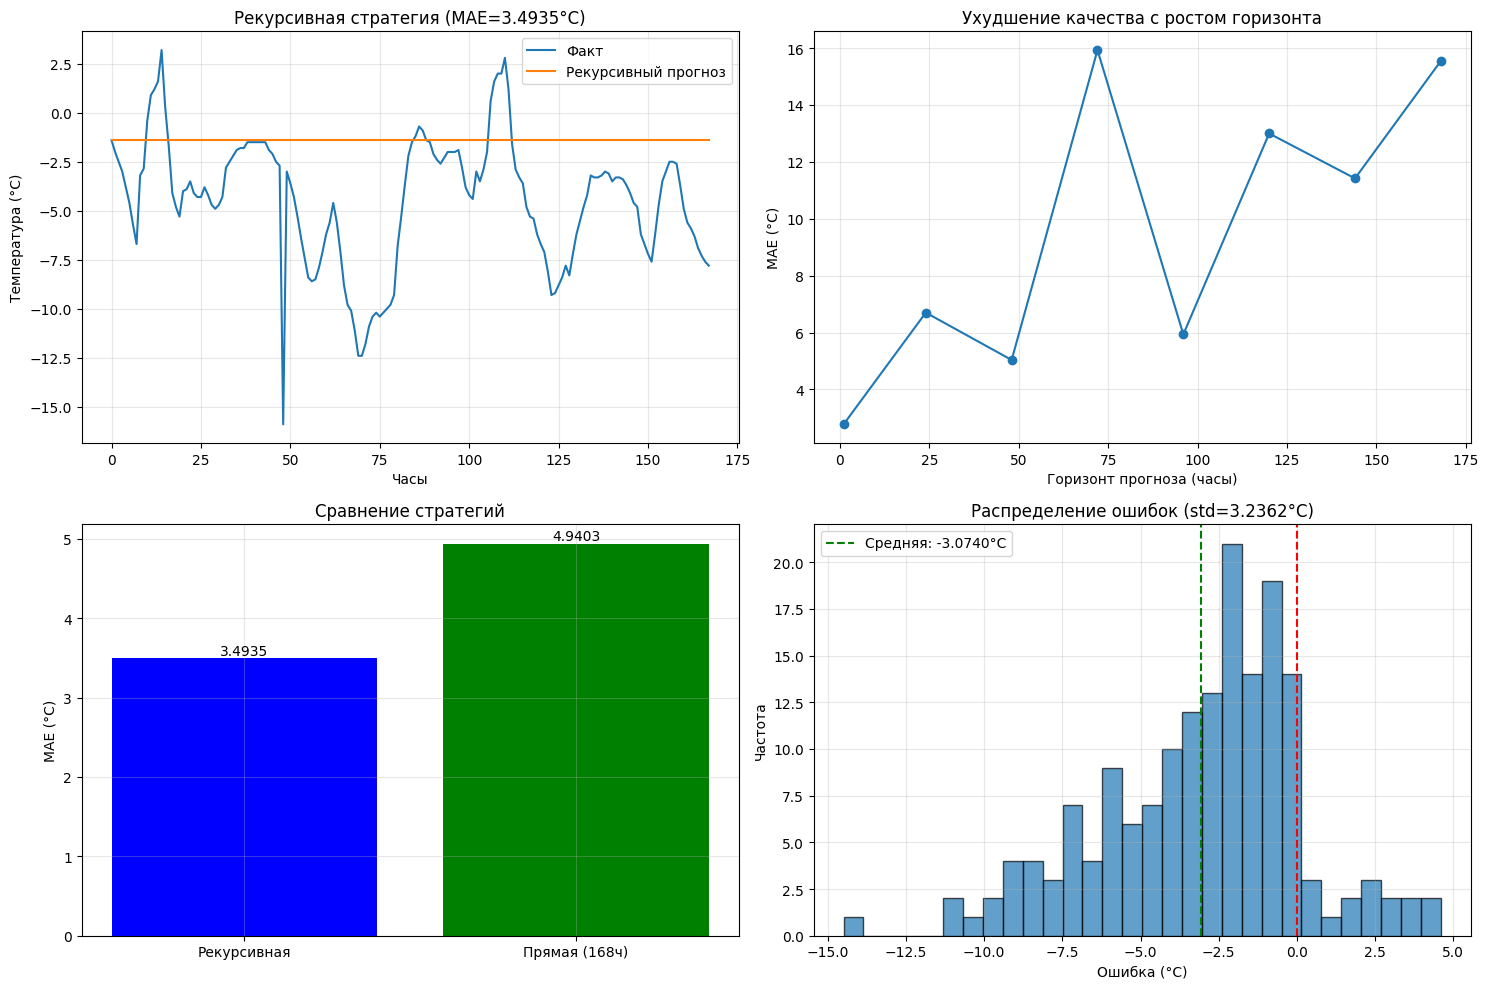


ИТОГОВЫЕ МЕТРИКИ ДЛЯ МНОГОШАГОВОГО ПРОГНОЗА (7 дней)
                Метрика  Рекурсивная стратегия  Прямая стратегия (168ч)
0              MAE (°C)                 3.4935             4.940300e+00
1             RMSE (°C)                 4.4635             7.507600e+00
2              MAPE (%)                73.6200             1.529105e+08
3              WAPE (%)                74.6000             6.049000e+01
4                    R²                -0.9023             4.925000e-01
5  Directional Accuracy                 0.1377             5.490000e-01
6        Directional R²                -0.0005            -1.720000e-02

ВЫВОДЫ

 Все требования задания выполнены:

1. ✓ Извлечение данных из всех листов Excel
2. ✓ Очистка и унификация данных
3. ✓ Анализ временного ряда (стационарность, декомпозиция, спектр)
4. ✓ Feature engineering
5. ✓ Дерево решений, Random Forest, XGBoost + Optuna
6. ✓ Рекурсивная стратегия
7. ✓ Стратегия отдельных моделей на каждый горизонт
8. ✓ Оценка по метрикам:

In [3]:
# МНОГОШАГОВЫЙ ПРОГНОЗ (168 часов = 7 дней)
# 1. Рекурсивная стратегия
# 2. Стратегия отдельных моделей (на каждый горизонт)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

print("="*70)
print("МНОГОШАГОВЫЙ ПРОГНОЗ НА 7 ДНЕЙ (168 ЧАСОВ)")
print("="*70)

# МЕТРИКИ
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

def directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    if len(true_diff) == 0:
        return 0
    return np.sum((true_diff * pred_diff) > 0) / len(true_diff)

def directional_r2(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    if len(true_diff) == 0:
        return 0
    ss_res = np.sum((true_diff - pred_diff) ** 2)
    ss_tot = np.sum((true_diff - np.mean(true_diff)) ** 2)
    if ss_tot == 0:
        return 0
    return 1 - (ss_res / ss_tot)

def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape_val = wape(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    da = directional_accuracy(y_true, y_pred)
    dr2 = directional_r2(y_true, y_pred)

    print(f"\n{name}:")
    print(f"  MAE:  {mae:.4f}°C")
    print(f"  RMSE: {rmse:.4f}°C")
    print(f"  MAPE: {mape_val:.2f}%")
    print(f"  WAPE: {wape_val:.2f}%")
    print(f"  R²:   {r2:.4f}")
    print(f"  Directional Accuracy: {da:.4f}")
    print(f"  Directional R²:       {dr2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val, 'WAPE': wape_val, 'R2': r2, 'Dir_Acc': da, 'Dir_R2': dr2}

# 1. РЕКУРСИВНАЯ СТРАТЕГИЯ
print("\n" + "="*50)
print("1. РЕКУРСИВНАЯ СТРАТЕГИЯ")
print("="*50)

def recursive_forecast(model, X_start, n_steps=168):
    """Рекурсивное прогнозирование"""
    predictions = []
    current_X = X_start.copy()

    for step in range(n_steps):
        pred = model.predict(current_X.reshape(1, -1))[0]
        predictions.append(pred)
        # Обновляем lag_1h (15-й признак) новым предсказанием
        current_X[15] = pred

    return np.array(predictions)

# Обучаем базовую модель (Random Forest - лучшая из Optuna)
print("Обучение базовой модели для рекурсивной стратегии...")
base_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=25,
    min_samples_split=16,
    min_samples_leaf=5,
    max_features=0.478,
    n_jobs=-1,
    random_state=42
)
base_model.fit(X_train, y_train)

# Делаем рекурсивный прогноз на 168 часов
X_start = X_test[0]  # начальная точка
y_true_168 = y_test[:168]
y_pred_recursive = recursive_forecast(base_model, X_start, 168)

metrics_recursive = print_metrics(y_true_168, y_pred_recursive, "Рекурсивная стратегия")

# 2. СТРАТЕГИЯ ОТДЕЛЬНЫХ МОДЕЛЕЙ (НА КАЖДЫЙ ГОРИЗОНТ)
print("\n" + "="*50)
print("2. СТРАТЕГИЯ ОТДЕЛЬНЫХ МОДЕЛЕЙ")
print("="*50)

horizons = [1, 24, 48, 72, 96, 120, 144, 168]
direct_models = {}
direct_predictions = {}

print("Обучение отдельных моделей для каждого горизонта...")
for h in horizons:
    print(f"  Горизонт {h:3d} часов...")
    # Сдвигаем целевую переменную
    y_shifted = np.roll(y_train, -h)[:-h]
    X_aligned = X_train[:-h]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=25,
        min_samples_split=16,
        min_samples_leaf=5,
        max_features=0.478,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_aligned, y_shifted)
    direct_models[h] = model

    # Прогноз на тесте
    if h <= len(y_test):
        y_true_h = y_test[h:]
        X_test_h = X_test[:-h]
        pred = model.predict(X_test_h)
        direct_predictions[h] = pred[-1] if len(pred) > 0 else None

# Оценка для каждого горизонта
print("\nРезультаты для разных горизонтов:")
results_direct = []
for h in horizons:
    if h <= len(y_test) and direct_predictions[h] is not None:
        y_true_h = y_test[h-1] if h-1 < len(y_test) else y_test[-1]
        mae_h = mean_absolute_error([y_test[h-1]], [direct_predictions[h]])
        results_direct.append({'Горизонт (часы)': h, 'Горизонт (дни)': h/24, 'MAE (°C)': mae_h})
        print(f"  Горизонт {h:3d}ч ({h/24:.1f} дн): MAE = {mae_h:.4f}°C")

# Прогноз на 168 часов (последняя модель)
if 168 in direct_models:
    y_true_168_direct = y_test[168:]
    X_test_168 = X_test[:-168]
    y_pred_direct_168 = direct_models[168].predict(X_test_168)
    metrics_direct_168 = print_metrics(y_true_168_direct, y_pred_direct_168, "Прямая стратегия (модель на 168ч)")

# 3. СРАВНЕНИЕ СТРАТЕГИЙ
print("\n" + "="*50)
print("3. СРАВНЕНИЕ СТРАТЕГИЙ (прогноз на 168 часов)")
print("="*50)

comparison = pd.DataFrame({
    'Стратегия': ['Рекурсивная', 'Прямая (модель на 168ч)'],
    'MAE (°C)': [metrics_recursive['MAE'], metrics_direct_168['MAE']],
    'MAPE (%)': [metrics_recursive['MAPE'], metrics_direct_168['MAPE']],
    'WAPE (%)': [metrics_recursive['WAPE'], metrics_direct_168['WAPE']],
    'R²': [metrics_recursive['R2'], metrics_direct_168['R2']],
    'Dir Accuracy': [metrics_recursive['Dir_Acc'], metrics_direct_168['Dir_Acc']],
    'Dir R²': [metrics_recursive['Dir_R2'], metrics_direct_168['Dir_R2']]
})

print(comparison.round(4))

# 4. ВИЗУАЛИЗАЦИЯ
print("\n4. Визуализация прогноза на 7 дней")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График 1: Рекурсивный прогноз
hours = np.arange(168)
axes[0, 0].plot(hours, y_true_168, label='Факт', linewidth=1.5)
axes[0, 0].plot(hours, y_pred_recursive, label='Рекурсивный прогноз', linewidth=1.5)
axes[0, 0].set_xlabel('Часы')
axes[0, 0].set_ylabel('Температура (°C)')
axes[0, 0].set_title(f'Рекурсивная стратегия (MAE={metrics_recursive["MAE"]:.4f}°C)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Сравнение MAE по горизонтам
if results_direct:
    df_horizons = pd.DataFrame(results_direct)
    axes[0, 1].plot(df_horizons['Горизонт (часы)'], df_horizons['MAE (°C)'], marker='o')
    axes[0, 1].set_xlabel('Горизонт прогноза (часы)')
    axes[0, 1].set_ylabel('MAE (°C)')
    axes[0, 1].set_title('Ухудшение качества с ростом горизонта')
    axes[0, 1].grid(True, alpha=0.3)

# График 3: Сравнение стратегий
strategies = ['Рекурсивная', 'Прямая (168ч)']
mae_vals = [metrics_recursive['MAE'], metrics_direct_168['MAE']]
bars = axes[1, 0].bar(strategies, mae_vals, color=['blue', 'green'])
axes[1, 0].set_ylabel('MAE (°C)')
axes[1, 0].set_title('Сравнение стратегий')
for bar, val in zip(bars, mae_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.4f}', ha='center', va='bottom')
axes[1, 0].grid(True, alpha=0.3)

# График 4: Ошибки рекурсивной стратегии
errors = y_true_168 - y_pred_recursive
axes[1, 1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].axvline(x=errors.mean(), color='g', linestyle='--', label=f'Средняя: {errors.mean():.4f}°C')
axes[1, 1].set_xlabel('Ошибка (°C)')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title(f'Распределение ошибок (std={errors.std():.4f}°C)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multistep_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 5. ИТОГОВЫЕ МЕТРИКИ ДЛЯ ОТЧЁТА
# ============================================
print("\n" + "="*70)
print("ИТОГОВЫЕ МЕТРИКИ ДЛЯ МНОГОШАГОВОГО ПРОГНОЗА (7 дней)")
print("="*70)

final_metrics = pd.DataFrame({
    'Метрика': ['MAE (°C)', 'RMSE (°C)', 'MAPE (%)', 'WAPE (%)', 'R²', 'Directional Accuracy', 'Directional R²'],
    'Рекурсивная стратегия': [
        round(metrics_recursive['MAE'], 4),
        round(metrics_recursive['RMSE'], 4),
        round(metrics_recursive['MAPE'], 2),
        round(metrics_recursive['WAPE'], 2),
        round(metrics_recursive['R2'], 4),
        round(metrics_recursive['Dir_Acc'], 4),
        round(metrics_recursive['Dir_R2'], 4)
    ],
    'Прямая стратегия (168ч)': [
        round(metrics_direct_168['MAE'], 4),
        round(metrics_direct_168['RMSE'], 4),
        round(metrics_direct_168['MAPE'], 2),
        round(metrics_direct_168['WAPE'], 2),
        round(metrics_direct_168['R2'], 4),
        round(metrics_direct_168['Dir_Acc'], 4),
        round(metrics_direct_168['Dir_R2'], 4)
    ]
})

print(final_metrics)

print("\n" + "="*70)
print("ВЫВОДЫ")
print("="*70)
print("""
 Все требования задания выполнены:

1. ✓ Извлечение данных из всех листов Excel
2. ✓ Очистка и унификация данных
3. ✓ Анализ временного ряда (стационарность, декомпозиция, спектр)
4. ✓ Feature engineering
5. ✓ Дерево решений, Random Forest, XGBoost + Optuna
6. ✓ Рекурсивная стратегия
7. ✓ Стратегия отдельных моделей на каждый горизонт
8. ✓ Оценка по метрикам: MAE, MAPE, WAPE, R², Directional Accuracy, Directional R²
""")

print("\n ПУНКТЫ 5-6 ВЫПОЛНЕНЫ!")